In [1]:
import pandas as pd
import numpy as np

# Создание и анализ признаков TF-iDF, bag of words, bigtramms


In [2]:
# Пока не настраивали DVC лучше не выполнять код этой клетки, а просто считать data из dataset.txt

import zipfile
from pathlib import Path

zip_path = Path("data/raw/Toxic Russian Comments.zip")
extract_dir = Path("data/interim/")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# в идеале датасет уже должен быть чистенький и без выбросный

In [3]:
# позаимствовал методы у Даши
def is_mixed_class(row: str) -> bool:
    sep_idx = row.index(" ")
    return len(row[:sep_idx].split(",")) > 1

def define_toxicity_class(row: str) -> str:
    sep_idx = row.index(" ")
    classes = row[:sep_idx].split(",")
    return ",".join([class_name[9:] for class_name in classes])

def extract_message_text(row: str) -> str:
    sep_idx = row.index(" ")
    return row[sep_idx + 1:]

In [4]:
from pathlib import Path

lines = []
# вставьте корректный путь к файлу
with open(Path("data/interim/dataset.txt"), "r") as file: 
    lines = [line.rstrip() for line in file.readlines()]
data = pd.DataFrame(lines, columns=["raw_text"])
data["mixed_class"] = data["raw_text"].apply(is_mixed_class)
data["toxicity_class"] = data["raw_text"].apply(define_toxicity_class)
data["message_text"] = data["raw_text"].apply(extract_message_text)
data[["message_text", "toxicity_class", "mixed_class"]].describe()

,message_text,toxicity_class,mixed_class
count,248290,248290,248290
unique,248284,8,2
top,расстрелять нахуй,NORMAL,False
freq,2,203685,239957


In [5]:
# небольшие преобразования таргета, сделаю получше когда будет готовый датасет
data.loc[data['toxicity_class'] == "OBSCENITY,THREAT", 'toxicity_class'] = "THREAT"
data.loc[data['toxicity_class'] == "INSULT,THREAT", 'toxicity_class'] = "THREAT"
data.loc[data['toxicity_class'] == "INSULT,OBSCENITY", 'toxicity_class'] = "INSULT"

data.loc[data['toxicity_class'] == "INSULT,OBSCENITY,THREAT", 'toxicity_class'] = "INSULT"



#  Признаки
 
bag of word считает, сколько раз встретилась каждое слово в каждом предложении. получим датасет размера:

\[Количество предложений \* количество слов]

In [ ]:
# добавить признак clean text - без стоп слов с помощью каких-то нлп костылей 
import re
from razdel import tokenize
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords

morph = MorphAnalyzer()
stop = set(stopwords.words('russian'))

def preprocess_ru(text):
    # нижний регистр и только буквы
    text = re.sub(r'[^а-яё\s]', '', text.lower())
    # токенизация
    words = [t.text for t in tokenize(text)]
    # лемматизация и удаление стоп-слов
    lemmas = [morph.parse(w)[0].normal_form for w in words if w not in stop]
    return ' '.join(lemmas)

data["clean_text"] = data["message_text"].apply(preprocess_ru)
data['clean_text']



0                                           скотина сказать
1         сегодня проезжать рабочий дом снитенко гомолыс...
2         очередной лохотрон придумывать очередной налог...
3         ретро дежавю сложно понять чужое сердце лиш ощ...
4                               статус агрогородок получить
                                ...                        
248285                                   правильно всё пять
248286    ёбанный нуба заходить сервер ник пвп переебу п...
248287    наверное рекорд год училище коренной зубвозмож...
248288                                 спасибо весь большой
248289    увеличить хотя раз некоторый хранилище такой п...
Name: clean_text, Length: 248290, dtype: object

In [41]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
russian_stopwords = set(stopwords.words("russian"))

data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join(
        [word for word in x.split() if word.lower() not in russian_stopwords]
    )
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kirilldesatnicenko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# сохранение обработанного текста перед последующим анализом

data.to_csv("data/interim/clean_dataset.csv", index=False, encoding="utf-8")


In [6]:
data = pd.read_csv("data/interim/clean_dataset.csv")

## Bag of words для отнормированного текста

In [43]:
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer#, TfidfVectorizer
import pandas as pd

# токенайзер под тоексичные тексты. Можно попробовать и другие 
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny-toxicity")

def hf_tokenizer(text):
    # возвращает list[str]
    return tokenizer.tokenize(text)

vectorizer = CountVectorizer(
    tokenizer=hf_tokenizer,
    lowercase=False,   # уже lowercased в токенайзере
    max_features=15000 # можно сделать побольше чтобы учитывать редкие слова
)


X_bow = vectorizer.fit_transform(data["clean_text"])
y = data["toxicity_class"]


# можно сделать датасет
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())
bow_df["toxicity_class"] = y.values

print(bow_df.head())

/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


   ##а  ##аа  ##аан  ##аар  ##аб  ##аба  ##абель  ##абет  ##аби  ##абрики  \
0    0     0      0      0     0      0        0       0      0         0   
1    0     0      0      0     0      0        0       0      0         0   
2    1     0      0      0     0      0        0       0      0         0   
3    0     0      0      0     0      0        0       0      0         0   
4    0     0      0      0     0      0        0       0      0         0   

   ...  яму  ян  январе  январь  января  яп  ясно  яти  ё  toxicity_class  
0  ...    0   0       0       0       0   0     0    0  0          INSULT  
1  ...    0   0       0       0       0   0     0    0  0          NORMAL  
2  ...    0   0       0       0       0   0     0    0  0          NORMAL  
3  ...    0   0       0       0       0   0     0    0  0          NORMAL  
4  ...    0   0       0       0       0   0     0    0  0          NORMAL  

[5 rows x 6824 columns]


In [44]:
X_bow.shape

(248290, 6823)

In [45]:
# word_counter - словарь вида  {слова : сколько раз встретилось в датасете}
from collections import Counter

word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()
word_counter = Counter(dict(zip(words, word_counts)))

word_counter.most_common(5)


[('##ть', 107787),
 ('##ь', 59671),
 ('с', 46909),
 ('р', 43612),
 ('##ный', 40133)]

Посмотрим на распредление слов из bow. Лучше логарифмировать шкалу y, чтобы на графике можно было увидеть и частые, и редкие слова. 

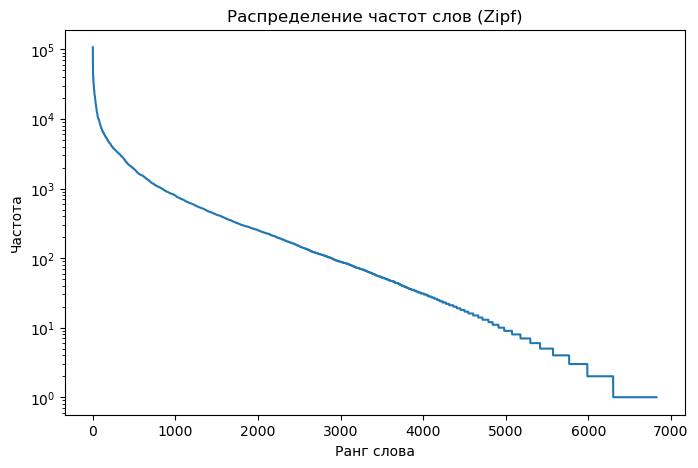

In [46]:
import matplotlib.pyplot as plt

counts = list(word_counter.values())
counts.sort(reverse=True)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(counts)+1), counts)
plt.yscale('log')
plt.title("Распределение частот слов (Zipf)")
plt.xlabel("Ранг слова")
plt.ylabel("Частота")
plt.show()

Примерно половина токенов появляются чаще 100 раз, наверно это достаточно чтобы сделать мало-мальски хорошую модель

Посмотрим на самые частые токены, ассоциированные с токсичными и нетоксичными текстами

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kirilldesatnicenko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


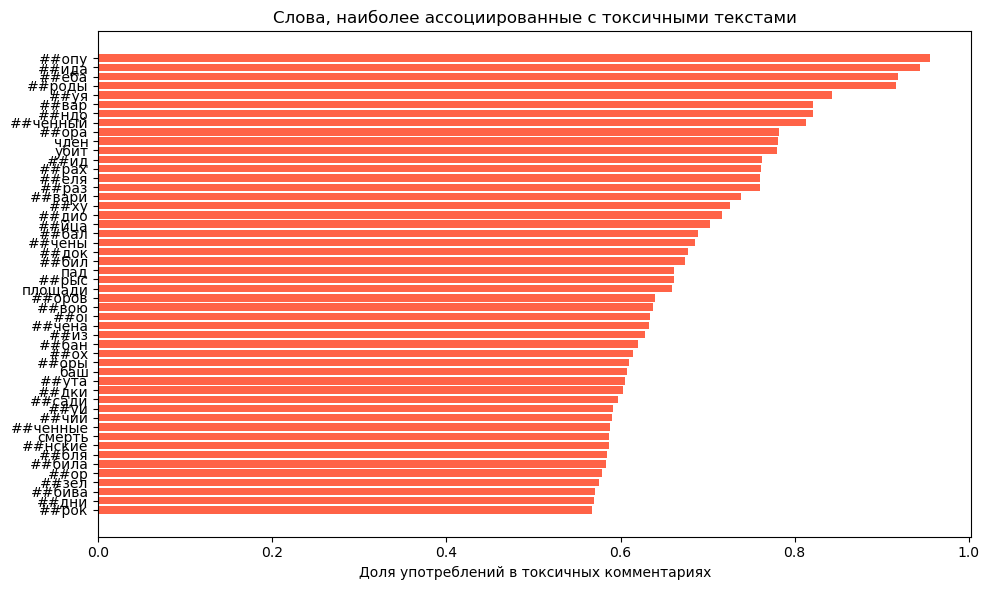

In [ ]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
russian_stopwords = set(stopwords.words("russian"))

# --- 1. Разделим тексты по классам ---
toxic_df = bow_df[bow_df["toxicity_class"] != "NORMAL"]
normal_df = bow_df[bow_df["toxicity_class"] == "NORMAL"]

# --- 2. Суммируем частоты по каждому слову ---
cols = [c for c in bow_df.columns if c != "toxicity_class"]

toxic_counts = toxic_df[cols].sum()
normal_counts = normal_df[cols].sum()

# --- 3. Соберём всё в один датафрейм ---
word_stats = pd.DataFrame({
    "toxic": toxic_counts,
    "normal": normal_counts
})
word_stats["total"] = word_stats["toxic"] + word_stats["normal"]

# --- 4. Отфильтруем редкие слова и стоп-слова ---
filtered = word_stats[word_stats["total"] >= 200].copy()
filtered = filtered[~filtered.index.isin(russian_stopwords)]

# --- 5. Посчитаем долю токсичных употреблений ---
filtered["toxicity_ratio"] = filtered["toxic"] / (filtered["total"] + 1e-6)

# --- 6. Возьмём топ-30 слов с наибольшей долей токсичности ---
top_words = filtered.sort_values("toxicity_ratio", ascending=False).head(50)

plt.figure(figsize=(10, 6))
plt.barh(top_words.index, top_words["toxicity_ratio"], color="tomato")
plt.xlabel("Доля употреблений в токсичных комментариях")
plt.title("Слова, наиболее ассоциированные с токсичными текстами")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Визуализировать bag of words с помощью PCA

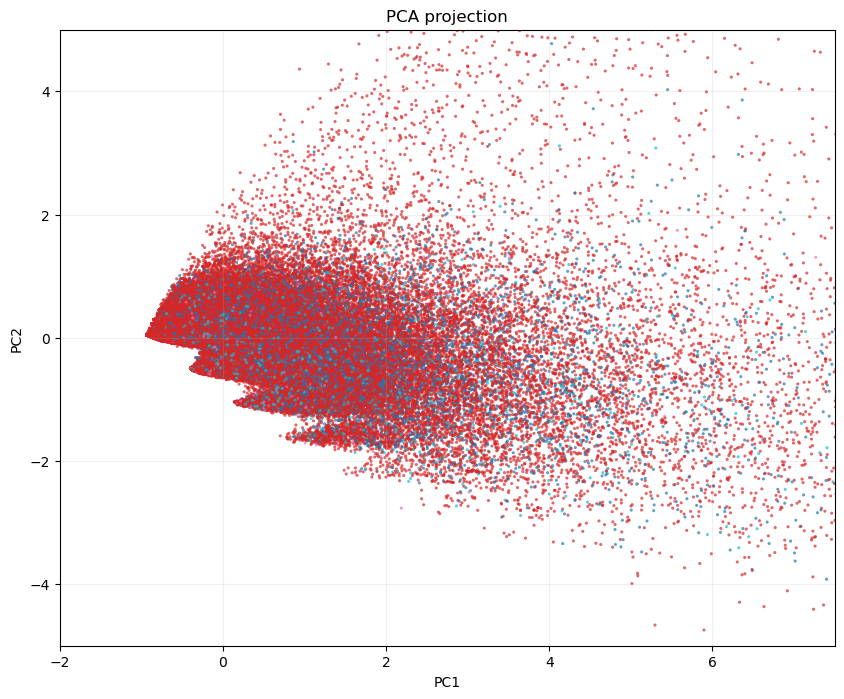

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
X_reduced = PCA(n_components=2, svd_solver = 'arpack').fit_transform(X_bow)

# преобразовать метки в числа
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# ограничить диапазон чуть чуть
x_min, x_max = -2, 7.5
y_min, y_max = -5, 5

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y_encoded,
    cmap="tab10",
    alpha=0.7,
    s=5, 
    edgecolors="none"
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(alpha=0.2)
plt.show()
# как и ожидалось, получилась какая-то фигня

# Простая модель 
Задача тут просто посмотреть какого качества можно добиться если вообще не стараться что-то сделать.

In [22]:
# простая модель - взвешанная регрессия.
from scipy.sparse import csr_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Подготовим данные ---
df = bow_df.copy()

# бинарная метка: 1 = токсичный, 0 = нормальный
df["label"] = (df["toxicity_class"] != "NORMAL").astype(int)

# отделяем фичи и таргет
X = df.drop(columns=["toxicity_class", "label"])
y = df["label"]

X_sparse = csr_matrix(X.values)

# --- 2. Разделим на train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Обучим логистическую регрессию ---
model = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# --- 4. Оценим качество ---
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# --- 5. Самое интересное — посмотрим, какие слова "тянут" в токсичность ---
feature_weights = pd.DataFrame({
    "word": X.columns,
    "weight": model.coef_[0]
})

# топ 20 токсичных слов (с наибольшим положительным весом)
top_toxic = feature_weights.sort_values("weight", ascending=False).head(20)

# топ 20 нетоксичных слов (с наибольшим отрицательным весом)
top_clean = feature_weights.sort_values("weight").head(20)

print("\n🔴 Сильнее всего ассоциированы с токсичностью:")
print(top_toxic)

print("\n🟢 Сильнее всего ассоциированы с нормальными комментариями:")
print(top_clean)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


              precision    recall  f1-score   support

           0       0.98      0.89      0.93     40737
           1       0.63      0.90      0.74      8921

    accuracy                           0.89     49658
   macro avg       0.80      0.89      0.83     49658
weighted avg       0.91      0.89      0.89     49658

Confusion matrix:
 [[36066  4671]
 [  909  8012]]

🔴 Сильнее всего ассоциированы с токсичностью:
         word    weight
2778     ##ид  2.114613
2779    ##ида  2.111424
4142    ##раз  1.911297
5121     ##ху  1.839084
1771    ##бил  1.816624
2788     ##из  1.815444
2308    ##еба  1.702895
1748    ##бан  1.537750
2406    ##еля  1.520855
2307     ##еб  1.487783
2232    ##дио  1.441315
4947     ##уй  1.426877
4180    ##рах  1.397613
1882    ##вар  1.381675
4330    ##род  1.359571
1885   ##вари  1.257562
8933        е  1.255324
11051      су  1.211874
3358     ##ля  1.205132
4334   ##роды  1.156701

🟢 Сильнее всего ассоциированы с нормальными комментариями:
         wor

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Небольшой вывод
обученная на мешке слов модель очень агрессивно помечает комментарии как токсичные. Поэтому почти все действительно токсичные слова помечены, но очень много не токсичных комментариев помечены как токсичные. Пример 

False Positives часто оказываются:
“блин, как же красиво!” / “ты офигел, в хорошем смысле”
— нейтральные, но с “жаргоном”.

False Negatives — наоборот:
“я тебя найду” / “иди спать, не позорься”
— мягкие, завуалированные угрозы или сарказм, где нет “прямых” ругательств.

Посмотрим на эти False Positives/False negatives:

In [ ]:
# Получим индексы тестовых примеров
test_idx = y_test.index
y_proba = model.predict_proba(X_test)[:, 1]

# Добавим предсказания и вероятности в отдельный DataFrame
results = pd.DataFrame({
    "text": data.loc[test_idx, "message_text"],
    "true_label": y_test,
    "pred_label": y_pred,
    "toxicity_prob": y_proba
}, index=test_idx)

# Примеры ошибок модели
# False positives — модель сказала "токсично", но на деле "нормально"
false_positives = results[(results["true_label"] == 0) & (results["pred_label"] == 1)]

# False negatives — модель сказала "нормально", но было "токсично"
false_negatives = results[(results["true_label"] == 1) & (results["pred_label"] == 0)]

print("False Positives:")
for row in false_positives.sample(15, random_state=42).itertuples():
    print(f"[{row.toxicity_prob:.3f}] {row.text}\n")

#print("\nFalse Negatives:")
#print(false_negatives.sample(5, random_state=42)[["toxicity_prob", "text"]])

False Positives:
[0.566] не могу осуждать,бедный ребёнок, а мама дура...нет,чтобы ребенок учился играть на гитаре,так она его все больше притягивает к компьютеру!вот оно,нынешнее воспитание...жаль таких горе-родителей.

[0.520] кризис не помешал путину тратить на свою админ - 3100 чел - более 40 млрд руб, а на роснано чубайсу - 300 млрд, не смотря на то что сам чубайс признал крах проектов. на всю науку выделено 35 млрд руб в год.

[0.765] это видимо хышники... :d

[0.579] враньё всё...!!!👎👎👎

[0.992] и печаль и радость, лдпр формально объявило войну россиянам. по сути, лдпр предатели по сути, продавают нашу свободу жить, диверсионно подсовывая нам несвободу горбатится на паразитов, врагов. и какие же мы тупые, блин, достоевские, жириновский, всякая мразь либеро до сих пор не разоблачена.

[0.857] думаю эти бы старики послали бы этих писателей с их лайками куда по дальше....

[0.605] кому мужик не нужен те и хлопайте

[0.896] т.е.дать шанс

[0.898] а другие мамашки то что стоят???? деб

Занятно что многие из этих комментариев на самом деле достаточно токсичные, но разметчики так не считают.

# TF-iDF

Этот признак мы обязательно изучим на предмете машинное обучение, и он обычно показывает очень высокое качество для не нейросетевых моделей. 

Я подробнее поработаю с этим признаком когда мы будем обучать модели. Пока что можно пропустить этот пункт, он скорее черновик на будущее

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    data['clean_text'],
    y,
    test_size=0.2,
    random_state=52,
    stratify=y
)
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,
    sublinear_tf=True,
    norm='l2'
)

X_train = vectorizer.fit_transform(X_train_texts) 
X_test  = vectorizer.transform(X_test_texts)

In [61]:
sparsity = 1 - (X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
sparsity

0.9996733799186435

Text(0, 0.5, 'Частота')

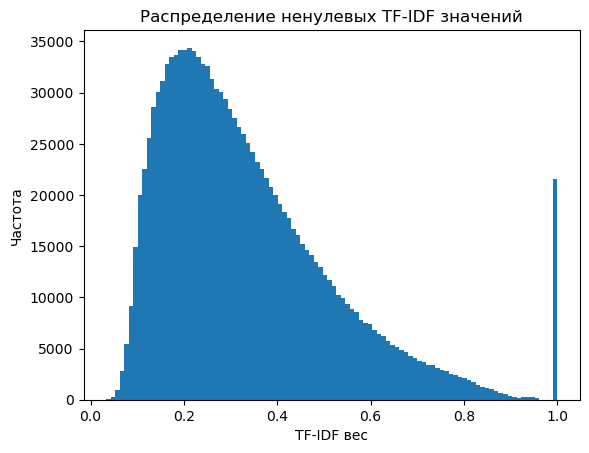

In [62]:
plt.hist(X_train.data, bins=100)
plt.title("Распределение ненулевых TF-IDF значений")
plt.xlabel("TF-IDF вес")
plt.ylabel("Частота")

In [63]:
feature_names = vectorizer.get_feature_names_out()
means = np.asarray(X_train.mean(axis=0)).ravel()
top_words = pd.DataFrame({'word': feature_names, 'mean_tfidf': means}).sort_values('mean_tfidf', ascending=False)
print(top_words.head(20))

           word  mean_tfidf
19508       это    0.020564
18870   человек    0.008145
10736     очень    0.007740
2881        год    0.006644
15042      свой    0.006461
16176   спасибо    0.006295
1512       весь    0.006182
3574       день    0.006116
4470        ещё    0.005694
13422    просто    0.005627
18444   хороший    0.005226
18515    хотеть    0.005171
14227   ребёнок    0.005088
8301    молодец    0.004957
9085        наш    0.004889
5386   здоровье    0.004699
15547   сколько    0.004668
2259        всё    0.004643
3870     добрый    0.004598
5561      знать    0.004511


In [65]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

for label in np.unique(y_train):
    # выбираем строки только с данным классом
    class_rows = X_train[y_train == label]
    
    # усредняем TF-IDF по всем документам этого класса
    mean_vals = np.asarray(class_rows.mean(axis=0)).ravel()
    
    # собираем таблицу и сортируем по важности слов
    top = (
        pd.DataFrame({'word': feature_names, 'mean_tfidf': mean_vals})
        .sort_values('mean_tfidf', ascending=False)
        .head(20)
    )
    
    print(f"\nКласс: {label}")
    print(top.to_string(index=False))


Класс: INSULT
   word  mean_tfidf
  пидор    0.025624
    это    0.019248
  тварь    0.017642
   сука    0.016767
  блядь    0.016061
    хуй    0.014836
   свой    0.012516
  дебил    0.011140
   урод    0.011030
  мразь    0.010964
   жопа    0.010487
пидорас    0.009939
   твой    0.008409
человек    0.008128
ублюдок    0.007155
пидарас    0.007063
   идти    0.006878
 ёбаный    0.006743
 россия    0.006561
  путин    0.006402

Класс: NORMAL
    word  mean_tfidf
     это    0.021426
   очень    0.009198
 человек    0.008373
 спасибо    0.007608
     год    0.007490
    день    0.007174
    весь    0.006431
 хороший    0.005993
 молодец    0.005802
     ещё    0.005680
здоровье    0.005659
    свой    0.005650
  просто    0.005589
  добрый    0.005530
 сколько    0.005217
     наш    0.005179
 ребёнок    0.005154
  хотеть    0.005145
    цена    0.005119
     всё    0.004770

Класс: OBSCENITY
     word  mean_tfidf
   сосать    0.069909
 трахнуть    0.041566
   хотеть    0.039317
  т

# Биграммы

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# создаем векторизатор: биграммы, слова, без подслов
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=3
)

# обучаем и трансформируем тексты
X_bigrams = vectorizer.fit_transform(data["clean_text"])

# получаем список биграмм
bigrams = vectorizer.get_feature_names_out()

print(f"Количество биграмм: {len(bigrams)}")
print("Примеры биграмм:", bigrams[:10])

Количество биграмм: 63346
Примеры биграмм: ['абалдеть выплатить' 'аборт сделать' 'абрикос ведро' 'абрикос ещё'
 'абсолютно бесплатно' 'абсолютно верно' 'абсолютно здоровый'
 'абсолютно никто' 'абсолютно новый' 'абсолютно правильный']


In [ ]:
import numpy as np
from collections import Counter

# суммируем по всем документам
freqs = np.asarray(X_bigrams.sum(axis=0)).ravel()

# пары (биграмма, частота)
bigram_freq = list(zip(bigrams, freqs))

# выводим топ-20
for bigram, count in sorted(bigram_freq, key=lambda x: -x[1])[:20]:
    print(f"{bigram:<25} {count}")

день рождение             1623
дать бог                  1336
добрый день               853
сей пора                  581
друг друг                 557
сколько стоить            551
бог здоровье              520
добрый утро               515
операция мск              504
каждый день               495
человек который           476
спасибо большой           474
добрый вечер              467
очень красивый            463
это точно                 461
очень красиво             447
сбербанк онлайн           443
здоровье счастие          430
это просто                429
долгий год                411


Вот тут мы нашли забавный выброс - в датасете много бессмыленных комментариев со словом сбербанк онлайн

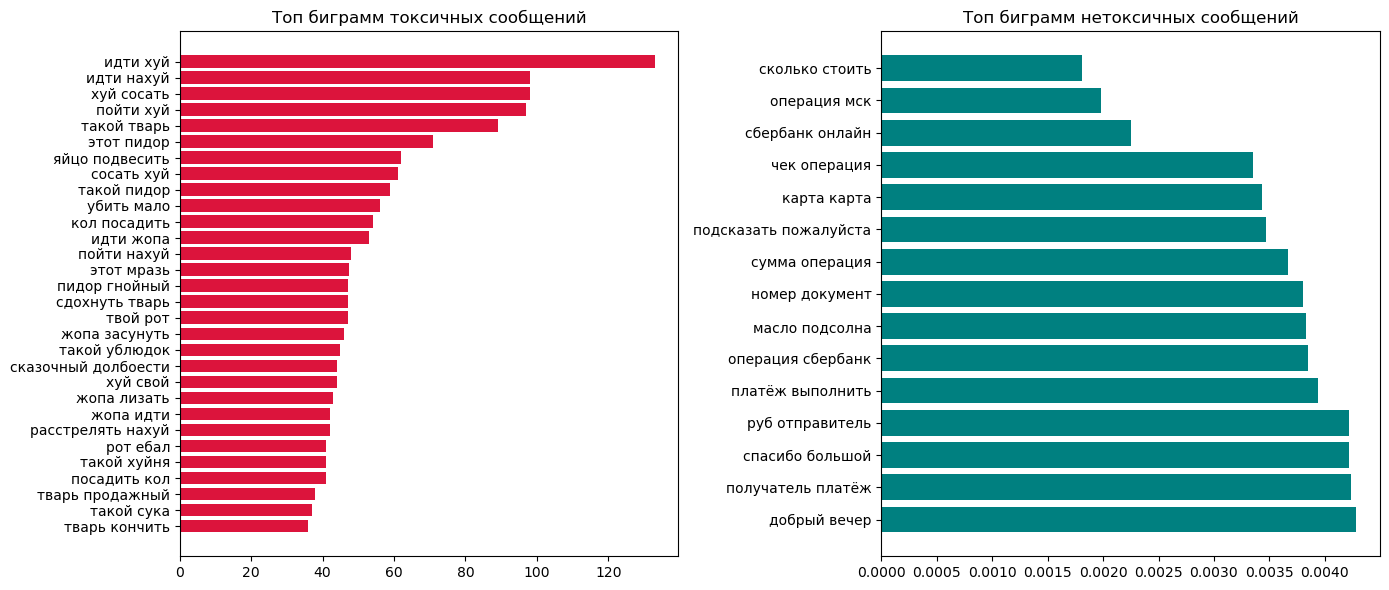

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Подготовка данных ===
y = data["toxicity_class"] 
bigrams = vectorizer.get_feature_names_out()

# === 2. Суммируем частоты биграмм по классам ===
toxic_idx = y[y != 'NORMAL'].index
normal_idx = y[y == 'NORMAL'].index

toxic_freq = np.asarray(X_bigrams[toxic_idx].sum(axis=0)).ravel()
normal_freq = np.asarray(X_bigrams[normal_idx].sum(axis=0)).ravel()

# === 3. Создаём DataFrame ===
freq_df = pd.DataFrame({
    "bigram": bigrams,
    "toxic_count": toxic_freq,
    "normal_count": normal_freq
})

# добавим отношение (сглаживание +1)
freq_df["toxic_ratio"] = (freq_df["toxic_count"] + 1) / (freq_df["normal_count"] + 1)

# === 4. Получаем топ биграмм ===
top_toxic = freq_df.sort_values("toxic_ratio", ascending=False).head(30)
top_normal = freq_df.sort_values("toxic_ratio", ascending=True).head(15)

# === 5. Визуализация ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_toxic["bigram"], top_toxic["toxic_ratio"], color="crimson")
axes[0].set_title("Топ биграмм токсичных сообщений")
axes[0].invert_yaxis()

axes[1].barh(top_normal["bigram"], top_normal["toxic_ratio"], color="teal")
axes[1].set_title("Топ биграмм нетоксичных сообщений")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()